In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [3]:
input_path = "../data/feature_engineered/vegetable_prices_fe.csv"
df = pd.read_csv(input_path)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (5028, 67)
Columns: ['vegetable', 'price', 'Badulla_actual_class', 'Hambantota_actual_class', 'Jaffna_actual_class', 'Kurunegala_actual_class', 'Matale_actual_class', 'Nuwara_Eliya_actual_class', 'Ratnapura_actual_class', 'Badulla_prob_drought', 'Hambantota_prob_drought', 'Jaffna_prob_drought', 'Kurunegala_prob_drought', 'Matale_prob_drought', 'Nuwara_Eliya_prob_drought', 'Ratnapura_prob_drought', 'Badulla_prob_flood_risk', 'Hambantota_prob_flood_risk', 'Jaffna_prob_flood_risk', 'Kurunegala_prob_flood_risk', 'Matale_prob_flood_risk', 'Nuwara_Eliya_prob_flood_risk', 'Ratnapura_prob_flood_risk', 'Badulla_prob_normal', 'Hambantota_prob_normal', 'Jaffna_prob_normal', 'Kurunegala_prob_normal', 'Matale_prob_normal', 'Nuwara_Eliya_prob_normal', 'Ratnapura_prob_normal', 'USD_LKR_avg', 'RateChange_avg_%', 'week_num', 'price_lag1', 'price_lag2', 'price_roll_mean_4', 'price_roll_std_4', 'avg_prob_drought', 'max_prob_drought', 'min_prob_drought', 'std_prob_drought', 'avg_prob_flood_

,vegetable,price,Badulla_actual_class,Hambantota_actual_class,Jaffna_actual_class,Kurunegala_actual_class,Matale_actual_class,Nuwara_Eliya_actual_class,Ratnapura_actual_class,Badulla_prob_drought,...,USD_LKR_avg_sq,RateChange_avg_%_sq,week_num_sq,week_sin,week_cos,veg_2,veg_3,veg_4,veg_5,veg_6
0,1,58.6,-1,0,-1,-1,-1,-1,0,1.0,...,13075.9225,0.0081,9,0.354605,0.935016,0,0,0,0,0
1,2,67.0,-1,0,-1,-1,-1,-1,0,1.0,...,13075.9225,0.0081,9,0.354605,0.935016,1,0,0,0,0
2,3,47.5,-1,0,-1,-1,-1,-1,0,1.0,...,13075.9225,0.0081,9,0.354605,0.935016,0,1,0,0,0
3,4,105.0,-1,0,-1,-1,-1,-1,0,1.0,...,13075.9225,0.0081,9,0.354605,0.935016,0,0,1,0,0
4,5,22.5,-1,0,-1,-1,-1,-1,0,1.0,...,13075.9225,0.0081,9,0.354605,0.935016,0,0,0,1,0


In [4]:
# Look at the first 100 rows to see week pattern
print("First 100 rows - week_num pattern:")
print(df['week_num'].head(100).tolist())

# Count how many times week_num resets from 52 to 1
resets = (df['week_num'].diff() < 0).sum()
print(f"\nNumber of times week_num resets (52→1): {resets}")
print(f"This suggests approximately {resets + 1} years of data.")

First 100 rows - week_num pattern:
[3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 19, 19, 19, 19]

Number of times week_num resets (52→1): 16
This suggests approximately 17 years of data.


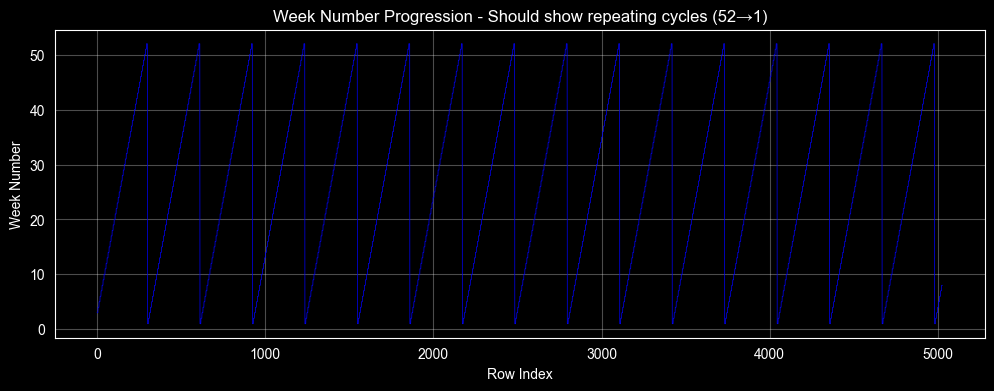

In [5]:
# Plot week_num over row index to verify chronology
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['week_num'], 'b-', linewidth=0.5)
plt.xlabel('Row Index')
plt.ylabel('Week Number')
plt.title('Week Number Progression - Should show repeating cycles (52→1)')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Find indices where week_num resets (52 → 1) - these mark year boundaries
reset_indices = df[df['week_num'].diff() < 0].index.tolist()

# Add start (0) and end (len(df)) for complete boundaries
year_boundaries = [0] + reset_indices + [len(df)]
print(f"Year boundaries at row indices: {year_boundaries}")
print(f"Total number of complete years: {len(year_boundaries) - 1}")

# Display each year's row range
for i in range(len(year_boundaries) - 1):
    start = year_boundaries[i]
    end = year_boundaries[i+1] - 1
    print(f"Year {i+1}: rows {start} to {end} ({end-start+1} rows)")

Year boundaries at row indices: [0, 300, 612, 924, 1236, 1548, 1860, 2172, 2484, 2796, 3108, 3420, 3732, 4044, 4356, 4668, 4980, 5028]
Total number of complete years: 17
Year 1: rows 0 to 299 (300 rows)
Year 2: rows 300 to 611 (312 rows)
Year 3: rows 612 to 923 (312 rows)
Year 4: rows 924 to 1235 (312 rows)
Year 5: rows 1236 to 1547 (312 rows)
Year 6: rows 1548 to 1859 (312 rows)
Year 7: rows 1860 to 2171 (312 rows)
Year 8: rows 2172 to 2483 (312 rows)
Year 9: rows 2484 to 2795 (312 rows)
Year 10: rows 2796 to 3107 (312 rows)
Year 11: rows 3108 to 3419 (312 rows)
Year 12: rows 3420 to 3731 (312 rows)
Year 13: rows 3732 to 4043 (312 rows)
Year 14: rows 4044 to 4355 (312 rows)
Year 15: rows 4356 to 4667 (312 rows)
Year 16: rows 4668 to 4979 (312 rows)
Year 17: rows 4980 to 5027 (48 rows)


In [7]:
# Calculate number of years for each set
total_years = len(year_boundaries) - 1
train_years = int(0.7 * total_years)
val_years = int(0.15 * total_years)
test_years = total_years - train_years - val_years

print(f"Total years: {total_years}")
print(f"Training: {train_years} years ({train_years/total_years:.1%})")
print(f"Validation: {val_years} years ({val_years/total_years:.1%})")
print(f"Test: {test_years} years ({test_years/total_years:.1%})")
print("-" * 50)

# Get row indices for each split
train_end_idx = year_boundaries[train_years]
val_end_idx = year_boundaries[train_years + val_years]

# Split the data
train_df = df.iloc[:train_end_idx].copy()
val_df = df.iloc[train_end_idx:val_end_idx].copy()
test_df = df.iloc[val_end_idx:].copy()

print(f"Training: rows 0 to {train_end_idx-1} (Years 1-{train_years})")
print(f"Validation: rows {train_end_idx} to {val_end_idx-1} (Years {train_years+1}-{train_years+val_years})")
print(f"Test: rows {val_end_idx} to {len(df)-1} (Years {train_years+val_years+1}-{total_years})")
print(f"\nTotal rows: {len(train_df) + len(val_df) + len(test_df)} = {len(df)}")

Total years: 17
Training: 11 years (64.7%)
Validation: 2 years (11.8%)
Test: 4 years (23.5%)
--------------------------------------------------
Training: rows 0 to 3419 (Years 1-11)
Validation: rows 3420 to 4043 (Years 12-13)
Test: rows 4044 to 5027 (Years 14-17)

Total rows: 5028 = 5028


In [8]:
print("=" * 60)
print("VERIFICATION OF SPLITS")
print("=" * 60)

# Training set info
print(f"\n📊 TRAINING SET:")
print(f"   Rows: 0 to {train_end_idx-1}")
print(f"   Year range: Years 1 to {train_years}")
print(f"   Week numbers present: {sorted(train_df['week_num'].unique())}")
print(f"   Total rows: {len(train_df)}")

# Validation set info
print(f"\n📊 VALIDATION SET:")
print(f"   Rows: {train_end_idx} to {val_end_idx-1}")
print(f"   Year range: Years {train_years+1} to {train_years+val_years}")
print(f"   Week numbers present: {sorted(val_df['week_num'].unique())}")
print(f"   Total rows: {len(val_df)}")

# Test set info
print(f"\n📊 TEST SET:")
print(f"   Rows: {val_end_idx} to {len(df)-1}")
print(f"   Year range: Years {train_years+val_years+1} to {total_years}")
print(f"   Week numbers present: {sorted(test_df['week_num'].unique())}")
print(f"   Total rows: {len(test_df)}")

# Verify clean breaks
print("\n" + "=" * 60)
print("BOUNDARY VERIFICATION:")
print(f"Last training row index: {train_end_idx-1}")
print(f"First validation row index: {train_end_idx}")
print(f"Last validation row index: {val_end_idx-1}")
print(f"First test row index: {val_end_idx}")

if train_end_idx == year_boundaries[train_years]:
    print("✅ Clean break between training and validation (end of year)")
if val_end_idx == year_boundaries[train_years + val_years]:
    print("✅ Clean break between validation and test (end of year)")

VERIFICATION OF SPLITS

📊 TRAINING SET:
   Rows: 0 to 3419
   Year range: Years 1 to 11
   Week numbers present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
   Total rows: 3420

📊 VALIDATION SET:
   Rows: 3420 to 4043
   Year range: Years 12 to 13
   Week numbers present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
   Total rows: 624

📊 TEST SET:
   Rows: 4044 to 5027
   Year range: Years 14 to 17
   Week numbers present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
   Total rows: 984

BOUNDARY VERIFICATION:
Last training row i

In [9]:
# Create a DataFrame showing which set each year belongs to
years_allocation = []
for i in range(total_years):
    start_row = year_boundaries[i]
    end_row = year_boundaries[i+1] - 1
    year_num = i + 1

    if year_num <= train_years:
        set_name = "TRAIN"
    elif year_num <= train_years + val_years:
        set_name = "VALIDATION"
    else:
        set_name = "TEST"

    years_allocation.append({
        'Year': year_num,
        'Set': set_name,
        'Start Row': start_row,
        'End Row': end_row,
        'Row Count': end_row - start_row + 1
    })

allocation_df = pd.DataFrame(years_allocation)
print("YEAR ALLOCATION DETAILS:")
print(allocation_df.to_string(index=False))

print("\n" + "=" * 60)
print("SUMMARY BY SET:")
print(allocation_df.groupby('Set')['Row Count'].sum().to_string())

YEAR ALLOCATION DETAILS:
 Year        Set  Start Row  End Row  Row Count
    1      TRAIN          0      299        300
    2      TRAIN        300      611        312
    3      TRAIN        612      923        312
    4      TRAIN        924     1235        312
    5      TRAIN       1236     1547        312
    6      TRAIN       1548     1859        312
    7      TRAIN       1860     2171        312
    8      TRAIN       2172     2483        312
    9      TRAIN       2484     2795        312
   10      TRAIN       2796     3107        312
   11      TRAIN       3108     3419        312
   12 VALIDATION       3420     3731        312
   13 VALIDATION       3732     4043        312
   14       TEST       4044     4355        312
   15       TEST       4356     4667        312
   16       TEST       4668     4979        312
   17       TEST       4980     5027         48

SUMMARY BY SET:
Set
TEST           984
TRAIN         3420
VALIDATION     624


In [10]:
# This check is now less critical since we split by years,
# but we'll verify that each set contains all 52 weeks
print("CHECKING WEEK COVERAGE:")
print("-" * 40)

train_weeks = set(train_df['week_num'].unique())
val_weeks = set(val_df['week_num'].unique())
test_weeks = set(test_df['week_num'].unique())

print(f"Training set weeks: {sorted(train_weeks)}")
print(f"Validation set weeks: {sorted(val_weeks)}")
print(f"Test set weeks: {sorted(test_weeks)}")

print(f"\nAll sets contain all 52 weeks: {train_weeks == val_weeks == test_weeks == set(range(1, 53))}")

CHECKING WEEK COVERAGE:
----------------------------------------
Training set weeks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
Validation set weeks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
Test set weeks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]

All sets contain all 52 weeks: True


In [11]:
output_dir = "../data/splits"
os.makedirs(output_dir, exist_ok=True)

# Save each split
train_df.to_csv(os.path.join(output_dir, "train.csv"), index=False)
val_df.to_csv(os.path.join(output_dir, "validation.csv"), index=False)
test_df.to_csv(os.path.join(output_dir, "test.csv"), index=False)

print(f"✅ SPLITS SAVED TO: {output_dir}")
print("-" * 50)
print(f"📁 train.csv: {len(train_df):,} rows ({train_years} years)")
print(f"📁 validation.csv: {len(val_df):,} rows ({val_years} years)")
print(f"📁 test.csv: {len(test_df):,} rows ({test_years} years)")
print("-" * 50)
print(f"Total rows saved: {len(train_df) + len(val_df) + len(test_df):,}")

# Also save split information for reference
split_info = pd.DataFrame([{
    'split': 'train',
    'years': f'1-{train_years}',
    'rows': len(train_df),
    'row_indices': f'0-{train_end_idx-1}'
}, {
    'split': 'validation',
    'years': f'{train_years+1}-{train_years+val_years}',
    'rows': len(val_df),
    'row_indices': f'{train_end_idx}-{val_end_idx-1}'
}, {
    'split': 'test',
    'years': f'{train_years+val_years+1}-{total_years}',
    'rows': len(test_df),
    'row_indices': f'{val_end_idx}-{len(df)-1}'
}])

split_info.to_csv(os.path.join(output_dir, "split_info.csv"), index=False)
print("\n📁 split_info.csv saved with split details")

✅ SPLITS SAVED TO: ../data/splits
--------------------------------------------------
📁 train.csv: 3,420 rows (11 years)
📁 validation.csv: 624 rows (2 years)
📁 test.csv: 984 rows (4 years)
--------------------------------------------------
Total rows saved: 5,028

📁 split_info.csv saved with split details


In [12]:
print("TRAINING SET - First 5 rows:")
print(train_df[['week_num', 'vegetable', 'price']].head())
print("\n" + "=" * 60)

print("VALIDATION SET - First 5 rows:")
print(val_df[['week_num', 'vegetable', 'price']].head())
print("\n" + "=" * 60)

print("TEST SET - First 5 rows:")
print(test_df[['week_num', 'vegetable', 'price']].head())

TRAINING SET - First 5 rows:
   week_num  vegetable  price
0         3          1   58.6
1         3          2   67.0
2         3          3   47.5
3         3          4  105.0
4         3          5   22.5

VALIDATION SET - First 5 rows:
      week_num  vegetable  price
3420         1          1  192.0
3421         1          2   58.0
3422         1          3   11.4
3423         1          4  102.0
3424         1          5   88.0

TEST SET - First 5 rows:
      week_num  vegetable  price
4044         1          1  280.0
4045         1          2  370.0
4046         1          3   77.0
4047         1          4  194.0
4048         1          5  124.0
